In [15]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [17]:
#Part (a)
# No Causal direction - prediction only 
# simulate data
# set seed for reproducibility
np.random.seed(42)

n = 10000

# predictors
# draws n Bernoulli trial (0 or 1) with success probability 0.5
X1 = np.random.binomial(1, 0.5, n)
X2 = np.random.binomial(1, 0.5, n)

# Y depends on X1 and X2
# computes outcome probabilities from X1 and X2, clips them to [0,1] and samples Y as Bernoulli outcomes
prob_Y = 0.3 + 0.3 * X1 + 0.3 * X2
prob_Y = np.clip(prob_Y, 0, 1)
Y = np.random.binomial(1, prob_Y)

# irrelevant variables
X3 = np.random.binomial(1, 0.5, n)
X4 = np.random.binomial(1, 0.5, n)

df_a = pd.DataFrame({"X1": X1, "X2": X2, "X3": X3, "X4": X4, "Y": Y})

print("Part (a): Markov Blanket = {X1, X2}")
print("no DAG needed, since pure prediction")

Part (a): Markov Blanket = {X1, X2}
no DAG needed, since pure prediction


Part (b): Markov Blanket = {X1, X2}




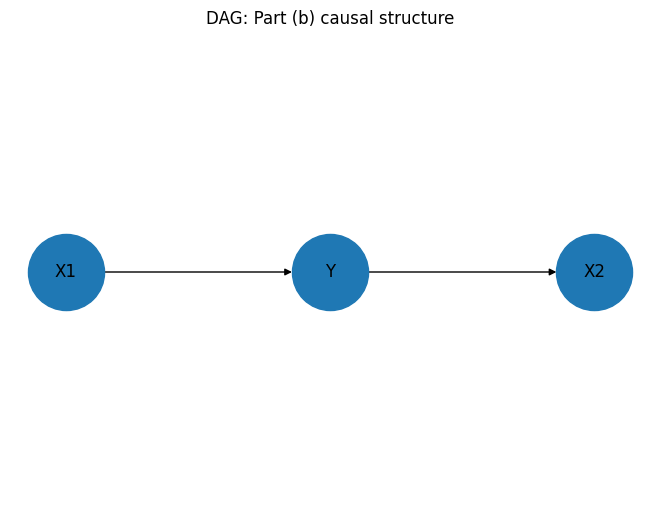

In [18]:
# Part (b) Causal Structure
# introduce causal ordering

# X1 causes Y
X1 = np.random.binomial(1, 0.5, n)

prob_Y = 0.4 + 0.3 * X1
prob_Y = np.clip(prob_Y, 0, 1)
Y = np.random.binomial(1, prob_Y)

# X2 is effect of Y
prob_X2 = 0.3 + 0.5 * Y
X2 = np.random.binomial(1, prob_X2)

# irrelevant variables
X3 = np.random.binomial(1, 0.5, n)
X4 = np.random.binomial(1, 0.5, n)

df_b = pd.DataFrame({"X1": X1, "Y": Y, "X2": X2, "X3": X3, "X4": X4})

print("Part (b): Markov Blanket = {X1, X2}\n\n")


G2 = nx.DiGraph()

G2.add_edges_from([
    ("X1", "Y"),
    ("Y", "X2")
])

pos2 = {
    "X1": (0, 1),
    "Y": (1, 1),
    "X2": (2, 1)
}

plt.figure()
nx.draw(G2, pos2, with_labels=True, node_size=3000)

plt.title("DAG: Part (b) causal structure")
plt.show()

In [12]:
# not part (a) or part (b) but EXTENSION: introduce confounder W

W = np.random.binomial(1, 0.5, n)

# X1 depends on W
prob_X1 = 0.3 + 0.4 * W
X1 = np.random.binomial(1, prob_X1)

# Y depends on both X1 and W
prob_Y = 0.2 + 0.3 * X1 + 0.3 * W
prob_Y = np.clip(prob_Y, 0, 1)
Y = np.random.binomial(1, prob_Y)

df_ext = pd.DataFrame({"W": W, "X1": X1, "Y": Y})
df_ext.head()

,W,X1,Y
0,0,0,0
1,0,1,1
2,1,1,1
3,0,0,0
4,0,0,1


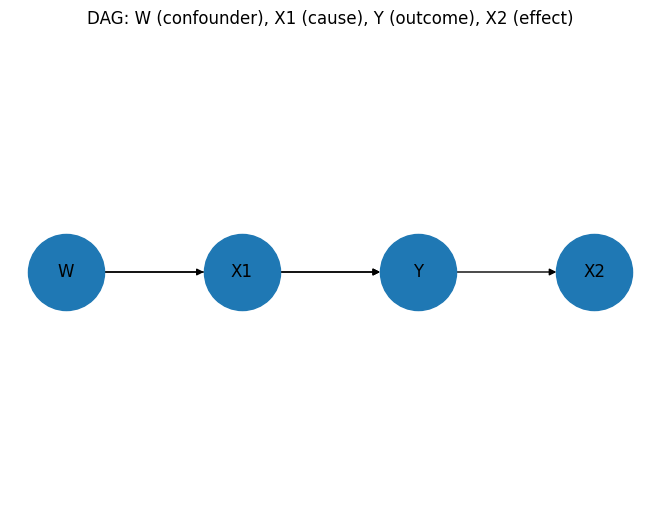

In [19]:
# create directed graph
G = nx.DiGraph()

# add edges (causal relationships)
G.add_edges_from([
    ("W", "X1"),   # confounder affects treatment
    ("W", "Y"),    # confounder affects outcome
    ("X1", "Y"),   # causal effect
    ("Y", "X2")    # outcome leads to effect
])

# layout
pos = {
    "W": (-1, 1),
    "X1": (0, 1),
    "Y": (1, 1),
    "X2": (2, 1)
}

# draw graph
plt.figure()
nx.draw(G, pos, with_labels=True, node_size=3000)

plt.title("DAG: W (confounder), X1 (cause), Y (outcome), X2 (effect)")
plt.show()

In [13]:
# naive estimate
naive = df_ext[df_ext["X1"] == 1]["Y"].mean() - \
        df_ext[df_ext["X1"] == 0]["Y"].mean()

print("Naive ACE:", round(naive, 3))

# backdoor adjustment
p_w0 = (df_ext["W"] == 0).mean()
p_w1 = (df_ext["W"] == 1).mean()

p_y_x1_1_w0 = df_ext[(df_ext["X1"] == 1) & (df_ext["W"] == 0)]["Y"].mean()
p_y_x1_1_w1 = df_ext[(df_ext["X1"] == 1) & (df_ext["W"] == 1)]["Y"].mean()

p_y_x1_0_w0 = df_ext[(df_ext["X1"] == 0) & (df_ext["W"] == 0)]["Y"].mean()
p_y_x1_0_w1 = df_ext[(df_ext["X1"] == 0) & (df_ext["W"] == 1)]["Y"].mean()

adjusted = (p_y_x1_1_w0 * p_w0 + p_y_x1_1_w1 * p_w1) - \
           (p_y_x1_0_w0 * p_w0 + p_y_x1_0_w1 * p_w1)

print("Adjusted ACE:", round(adjusted, 3))

Naive ACE: 0.418
Adjusted ACE: 0.308


In [14]:
print("""
Take-home Summary:
- Part (a): X1 and X2 are in the Markov Blanket because they predict Y
- Part (b): X1 is a cause of Y (occurs before), X2 is an effect (occurs after)
- Markov Blanket includes both causes and effects, but only prior variables can be causal
- Observational differences can be misleading when confounders are present
- Adjusting for confounders (like W) recovers the true causal effect
""")


Take-home Summary:
- Part (a): X1 and X2 are in the Markov Blanket because they predict Y
- Part (b): X1 is a cause of Y (occurs before), X2 is an effect (occurs after)
- Markov Blanket includes both causes and effects, but only prior variables can be causal
- Observational differences can be misleading when confounders are present
- Adjusting for confounders (like W) recovers the true causal effect

